In [16]:
import pandas as pd

df = pd.read_csv("/content/train (1).csv")

print(df.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [17]:
corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
print(corr.head(15))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


In [18]:
features = [
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'GarageArea',
    'TotalBsmtSF',
    '1stFlrSF',
    'FullBath',
    'TotRmsAbvGrd '
    'YearBuilt',
    'YearRemodAdd',
    'TotRmsAbvGrd',
    'GarageYrBlt',
    'MasVnrArea',
    'Fireplaces',
    'BsmtFinSF1'
]

In [19]:
df['TotalBath'] = (
    df['FullBath']
    + 0.5 * df['HalfBath']
    + df['BsmtFullBath']
    + 0.5 * df['BsmtHalfBath']
)

In [20]:
df['TotalArea'] = (
    df['GrLivArea']
    + df['TotalBsmtSF']
)

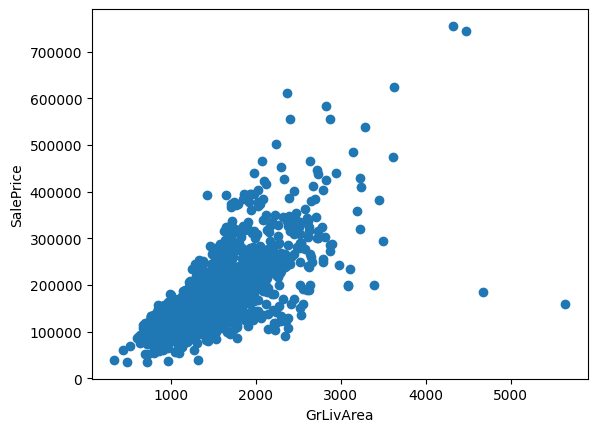

In [21]:
import matplotlib.pyplot as plt

plt.scatter(df['GrLivArea'], df['SalePrice'])
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

In [22]:
df = df[
    ~((df['GrLivArea'] > 4000) &
      (df['SalePrice'] < 300000))
]

<Axes: >

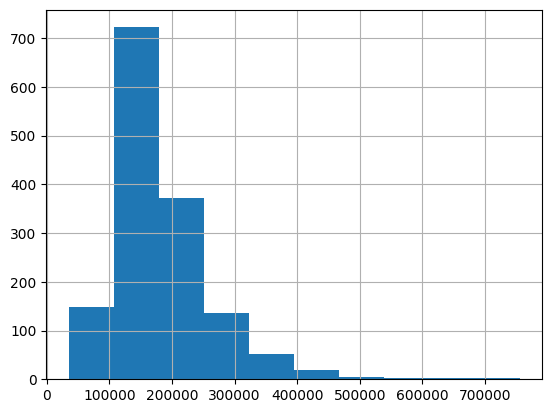

In [23]:
df['SalePrice'].hist()

In [24]:
import numpy as np

df['SalePrice'] = np.log1p(df['SalePrice'])

In [25]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [26]:
df_encoded

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,62.0,7917,6,5,1999,2000,0.0,0,...,False,False,False,False,True,False,False,False,True,False
1456,1457,20,85.0,13175,6,6,1978,1988,119.0,790,...,False,False,False,False,True,False,False,False,True,False
1457,1458,70,66.0,9042,7,9,1941,2006,0.0,275,...,False,False,False,False,True,False,False,False,True,False
1458,1459,20,68.0,9717,5,6,1950,1996,0.0,49,...,False,False,False,False,True,False,False,False,True,False


In [27]:
print(df_encoded.isnull().sum().sum())

348


In [28]:
df_encoded = df_encoded.fillna(df_encoded.median(numeric_only=True))

In [29]:
X = df_encoded.drop('SalePrice', axis=1)
y = df_encoded['SalePrice']

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [32]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score :", r2)
print("MAE :", mae)
print("RMSE :", rmse)

R² Score : 0.8919011517351414
MAE : 0.09180649261630827
RMSE : 0.13499222189394425


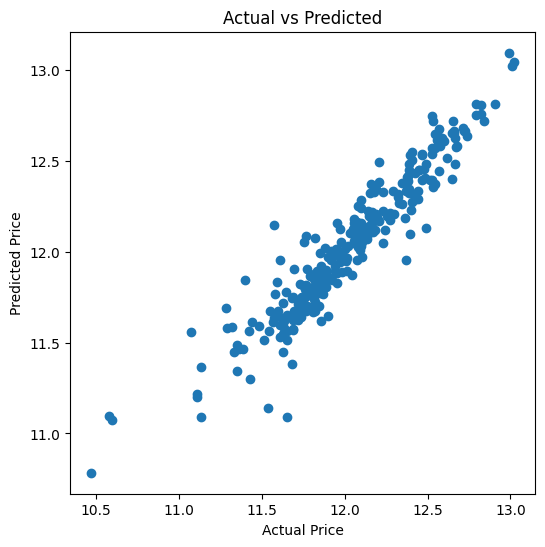

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [34]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})

coeff_df = coeff_df.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

print(coeff_df.head(20))

                   Feature  Coefficient
221          GarageCond_Po     0.577525
217          GarageQual_Po    -0.487117
39             MSZoning_FV     0.445497
238           SaleType_New     0.432733
41             MSZoning_RL     0.403096
40             MSZoning_RH     0.385079
215          GarageQual_Fa    -0.344917
42             MSZoning_RM     0.340559
245  SaleCondition_Partial    -0.331078
94         Condition2_RRAe    -0.328275
216          GarageQual_Gd    -0.301434
120    Exterior1st_BrkComm    -0.292789
218          GarageQual_TA    -0.290922
92         Condition2_PosA     0.272647
198        Functional_Maj2    -0.270464
220          GarageCond_Gd     0.268385
222          GarageCond_TA     0.264642
219          GarageCond_Fa     0.261560
90        Condition2_Feedr     0.260622
184           Heating_OthW     0.259828


In [35]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest R²:",
      r2_score(y_test, rf_pred))

Random Forest R²: 0.8681272506088553


In [36]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2 Score": [
        r2_score(y_test, y_pred),
        r2_score(y_test, rf_pred)
    ]
})

print(results)

               Model  R2 Score
0  Linear Regression  0.891901
1      Random Forest  0.868127


In [37]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    lr,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(scores)
print("Average:", scores.mean())

[0.89824119 0.89898316 0.88721629 0.91718772 0.89696054]
Average: 0.8997177825698939


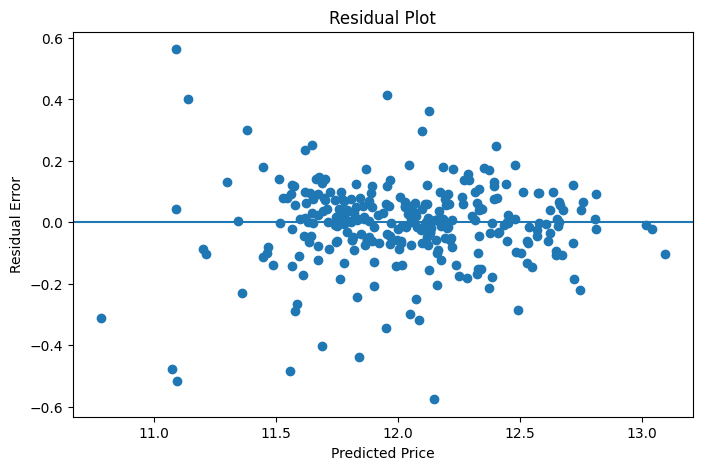

In [38]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Price")
plt.ylabel("Residual Error")
plt.title("Residual Plot")
plt.show()

In [41]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

params = {
    'alpha': [0.01, 0.1, 1, 10, 50, 100]
}

ridge = Ridge()

grid = GridSearchCV(
    ridge,
    params,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

print("Best Alpha:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Alpha: {'alpha': 10}
Best CV Score: 0.9149557992675728
